# Global model report

This notebook scans every model folder inside `./reports`, reads the available report artifacts, and creates a global comparison in `reports/_global`.

It is designed to keep working when new model folders are added later.

## Config

In [42]:
from pathlib import Path
import pandas as pd
from IPython.display import Markdown, display

REPORTS_DIR = Path("reports")
GLOBAL_REPORT_DIR = REPORTS_DIR / "_global"
GLOBAL_REPORT_DIR.mkdir(parents=True, exist_ok=True)

METRICS_FILE = "test_metrics.csv"
CLASSIFICATION_REPORT_FILE = "classification_report.csv"

EXPECTED_ARTIFACTS = [
    "test_metrics.csv",
    "classification_report.csv",
    "confusion_matrix.png",
    "accuracy.png",
    "loss.png",
    "recall.png",
    "f1score.png",
]

METRIC_ORDER = ["Accuracy", "Precision", "Recall", "Specificity", "F1 Score", "ROC-AUC"]
RANKING_METRICS = ["F1 Score", "ROC-AUC", "Accuracy"]

## Discover reports

In [43]:
def discover_model_dirs(reports_dir: Path) -> list[Path]:
    """Return every model report folder, excluding global/helper folders."""
    if not reports_dir.exists():
        raise FileNotFoundError(f"Reports folder not found: {reports_dir.resolve()}")

    return sorted(
        path
        for path in reports_dir.iterdir()
        if path.is_dir() and not path.name.startswith("_")
    )


def normalize_metric_name(metric: str) -> str:
    key = str(metric).strip().lower().replace("_", "-").replace(" ", "-")
    aliases = {
        "accuracy": "Accuracy",
        "acc": "Accuracy",
        "precision": "Precision",
        "recall": "Recall",
        "sensitivity": "Recall",
        "specificity": "Specificity",
        "f1": "F1 Score",
        "f1-score": "F1 Score",
        "f1score": "F1 Score",
        "roc-auc": "ROC-AUC",
        "roc_auc": "ROC-AUC",
        "auc": "ROC-AUC",
    }
    return aliases.get(key, str(metric).strip())


def read_test_metrics(model_dir: Path) -> dict:
    """Read metrics stored either as metric/value rows or as a one-row wide CSV."""
    csv_path = model_dir / METRICS_FILE
    row = {"model": model_dir.name, "report_path": str(model_dir)}

    if not csv_path.exists():
        row["status"] = "missing test_metrics.csv"
        return row

    df = pd.read_csv(csv_path)
    row["status"] = "ok"

    if set(["metric", "value"]).issubset(df.columns):
        for _, metric_row in df.iterrows():
            row[normalize_metric_name(metric_row["metric"])] = pd.to_numeric(metric_row["value"], errors="coerce")
    elif len(df) >= 1:
        first_row = df.iloc[0]
        for metric, value in first_row.items():
            row[normalize_metric_name(metric)] = pd.to_numeric(value, errors="coerce")
    else:
        row["status"] = "empty test_metrics.csv"

    return row


def read_classification_report(model_dir: Path) -> pd.DataFrame:
    csv_path = model_dir / CLASSIFICATION_REPORT_FILE
    if not csv_path.exists():
        return pd.DataFrame()

    df = pd.read_csv(csv_path)
    if "label" not in df.columns:
        return pd.DataFrame()

    df.insert(0, "model", model_dir.name)
    return df


def collect_missing_artifacts(model_dirs: list[Path]) -> pd.DataFrame:
    rows = []
    for model_dir in model_dirs:
        for artifact in EXPECTED_ARTIFACTS:
            rows.append({
                "model": model_dir.name,
                "artifact": artifact,
                "exists": (model_dir / artifact).exists(),
            })
    return pd.DataFrame(rows)


def dataframe_to_markdown(df: pd.DataFrame) -> str:
    """Create a simple Markdown table without requiring pandas optional dependencies."""
    if df.empty:
        return "No rows available."

    formatted_df = df.copy()
    for column in formatted_df.columns:
        if pd.api.types.is_numeric_dtype(formatted_df[column]):
            formatted_df[column] = formatted_df[column].map(lambda value: "" if pd.isna(value) else f"{value:.4f}")
        else:
            formatted_df[column] = formatted_df[column].fillna("").astype(str)

    header = "| " + " | ".join(formatted_df.columns) + " |"
    separator = "| " + " | ".join(["---"] * len(formatted_df.columns)) + " |"
    rows = ["| " + " | ".join(row) + " |" for row in formatted_df.to_numpy(dtype=str)]
    return "\n".join([header, separator] + rows)


model_dirs = discover_model_dirs(REPORTS_DIR)
display(Markdown(f"Found **{len(model_dirs)}** model report folders: " + ", ".join(f"`{p.name}`" for p in model_dirs)))

Found **7** model report folders: `cnn_propia_01`, `cnn_propia_02`, `cnn_propia_03`, `cnn_propia_04`, `cnn_propia_05`, `efficientnetb0`, `resnet50`

## Classification F1-Score Heatmap

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

classification_df = pd.concat(
    [read_classification_report(model_dir) for model_dir in model_dirs],
    ignore_index=True,
)

if not classification_df.empty:
    numeric_columns = ["precision", "recall", "f1-score", "support"]
    for column in numeric_columns:
        if column in classification_df.columns:
            classification_df[column] = pd.to_numeric(
                classification_df[column], errors="coerce"
            )

    # Filtrar solo clases reales
    plot_df = classification_df[
        ~classification_df["label"].isin(["accuracy", "macro avg", "weighted avg"])
    ].copy()

    # Crear matriz Clase x Modelo usando F1-score
    heatmap_data = plot_df.pivot(
        index="label",
        columns="model",
        values="f1-score",
    )

    data = heatmap_data.values

    plt.figure(figsize=(10, 6))
    im = plt.imshow(data, aspect="auto", vmin=0, vmax=1)

    plt.xticks(
        np.arange(len(heatmap_data.columns)),
        heatmap_data.columns,
        rotation=45,
        ha="right",
    )
    plt.yticks(
        np.arange(len(heatmap_data.index)),
        heatmap_data.index,
    )

    plt.colorbar(im, label="F1-score")
    plt.title("Heatmap - F1-score por Clase y Modelo")
    plt.xlabel("Modelo")
    plt.ylabel("Clase")

    plt.tight_layout()

    output_path = GLOBAL_REPORT_DIR / "classification_heatmap.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Heatmap saved to: {output_path}")

else:
    print("No `classification_report.csv` files were found.")

Heatmap saved to: reports\_global\classification_heatmap.png


## Full model comparative heatmap

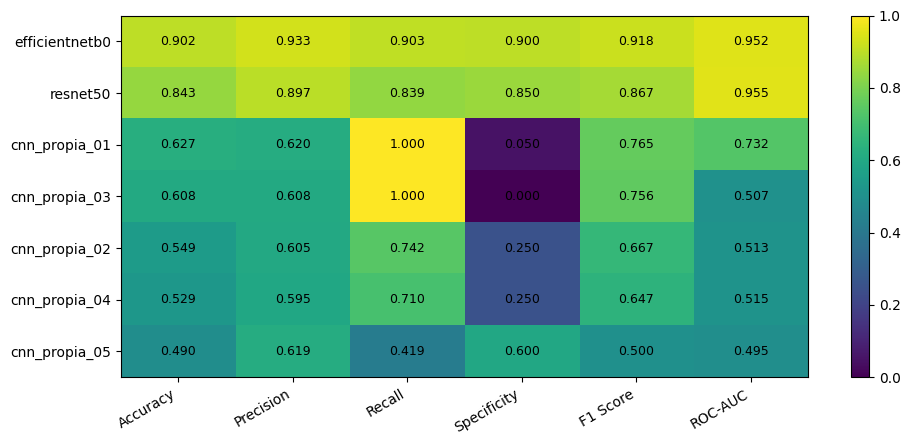

In [52]:
import matplotlib.pyplot as plt
import numpy as np

metrics_df = pd.DataFrame(
    read_test_metrics(model_dir)
    for model_dir in discover_model_dirs(REPORTS_DIR)
)

for metric in METRIC_ORDER:
    if metric in metrics_df:
        metrics_df[metric] = pd.to_numeric(metrics_df[metric], errors="coerce")

rank_metrics = [m for m in RANKING_METRICS if m in metrics_df]
if rank_metrics:
    metrics_df = metrics_df.sort_values(rank_metrics, ascending=False)

metrics = [
    m for m in METRIC_ORDER
    if m in metrics_df and metrics_df[m].notna().any()
]

if not metrics:
    display(Markdown("No numeric metrics were available to plot."))
else:
    plot_df = metrics_df.set_index("model")[metrics]

    fig, ax = plt.subplots(
        figsize=(
            max(10, len(metrics) * 1.4),
            max(3, len(plot_df) * 0.65)
        )
    )

    im = ax.imshow(
        plot_df.to_numpy(dtype=float),
        cmap="viridis",
        vmin=0,
        vmax=1,
        aspect="auto"
    )

    # Add values inside each heatmap cell
    values = plot_df.to_numpy(dtype=float)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            if not np.isnan(values[i, j]):
                ax.text(
                    j, i,
                    f"{values[i, j]:.3f}",  # adjust precision as desired
                    ha="center",
                    va="center",
                    color="black",
                    fontsize=9,
                )

    ax.set_xticks(range(len(plot_df.columns)), plot_df.columns)
    ax.set_yticks(range(len(plot_df.index)), plot_df.index)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(
        GLOBAL_REPORT_DIR / "global_metrics_heatmap.png",
        dpi=160,
        bbox_inches="tight"
    )
    plt.show()